# IRIS Dataset - Pandas 로드 및 탐색

In [9]:
import pandas as pd

# CSV 파일 로드
df = pd.read_csv('iris.csv')

print("=== 데이터 크기 ===")
print(f"행: {df.shape[0]}, 열: {df.shape[1]}\n")

print("=== 컬럼 정보 ===")
print(df.dtypes)
print()

print("=== 처음 10행 ===")
df.head(10)

=== 데이터 크기 ===
행: 150, 열: 5

=== 컬럼 정보 ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== 처음 10행 ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [10]:
# 기초 통계량 (평균, 표준편차, 최소/최대 등)
print("=== 기초 통계량 ===")
df.describe()

=== 기초 통계량 ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
# 품종별 샘플 수 확인
print("=== 품종별 데이터 수 ===")
print(df['species'].value_counts())
print()

# 품종별 평균값
print("=== 품종별 평균 ===")
df.groupby('species').mean().round(2)

=== 품종별 데이터 수 ===
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== 품종별 평균 ===


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


In [12]:
# 결측치 확인
print("=== 결측치 확인 ===")
print(df.isnull().sum())

=== 결측치 확인 ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 품종별 색상 팔레트
palette = {'Iris-setosa': '#4C72B0', 'Iris-versicolor': '#55A868', 'Iris-virginica': '#C44E52'}

### 1. 히스토그램 - 각 특성의 분포

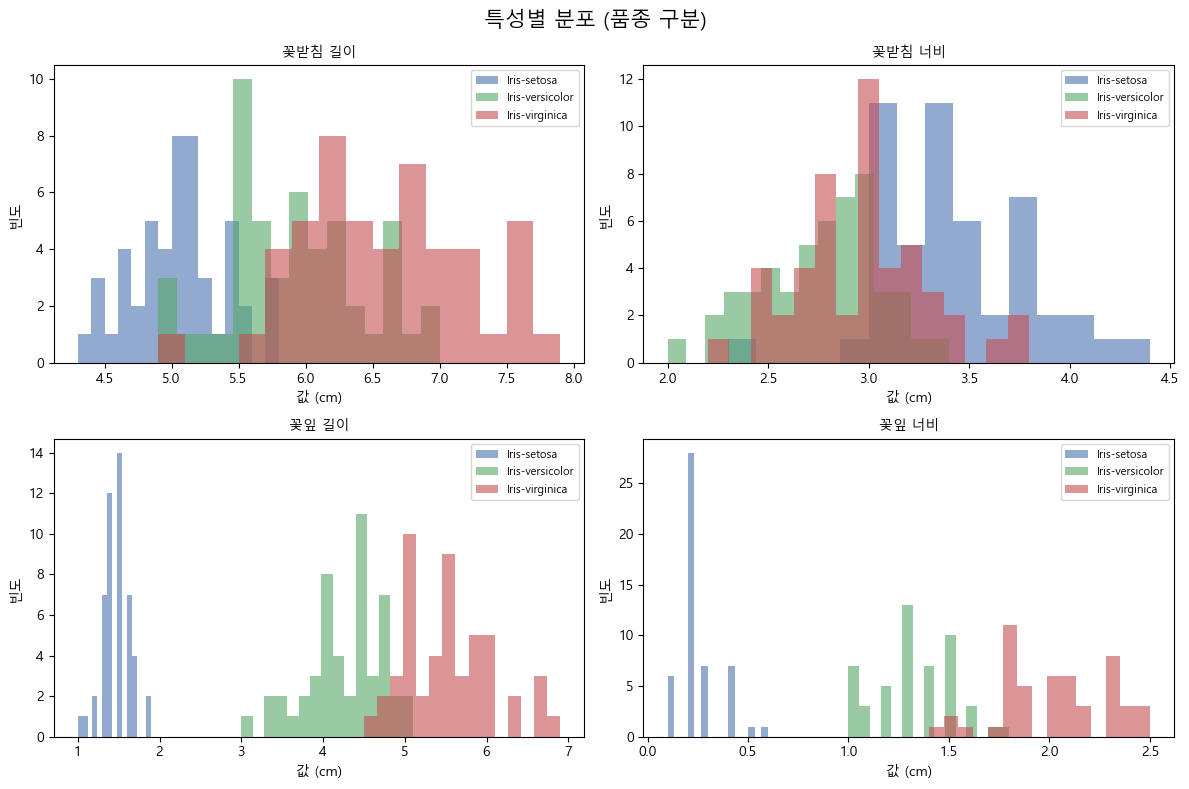

저장: 01_histogram.png


In [14]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
labels_ko = ['꽃받침 길이', '꽃받침 너비', '꽃잎 길이', '꽃잎 너비']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('특성별 분포 (품종 구분)', fontsize=15, fontproperties=font_prop)

for ax, feat, label in zip(axes.flatten(), features, labels_ko):
    for species, color in palette.items():
        subset = df[df['species'] == species][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=species)
    ax.set_title(label, fontproperties=font_prop)
    ax.set_xlabel('값 (cm)', fontproperties=font_prop)
    ax.set_ylabel('빈도', fontproperties=font_prop)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('01_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 01_histogram.png")

### 2. 박스플롯 - 품종별 특성 비교

C:\Users\user\AppData\Local\Temp\ipykernel_32524\1200243171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_32524\1200243171.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['setosa', 'versicolor', 'virginica'], fontsize=9)
C:\Users\user\AppData\Local\Temp\ipykernel_32524\1200243171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_32524\1200243171.py:10: UserWarning: set_ticklabels() sh

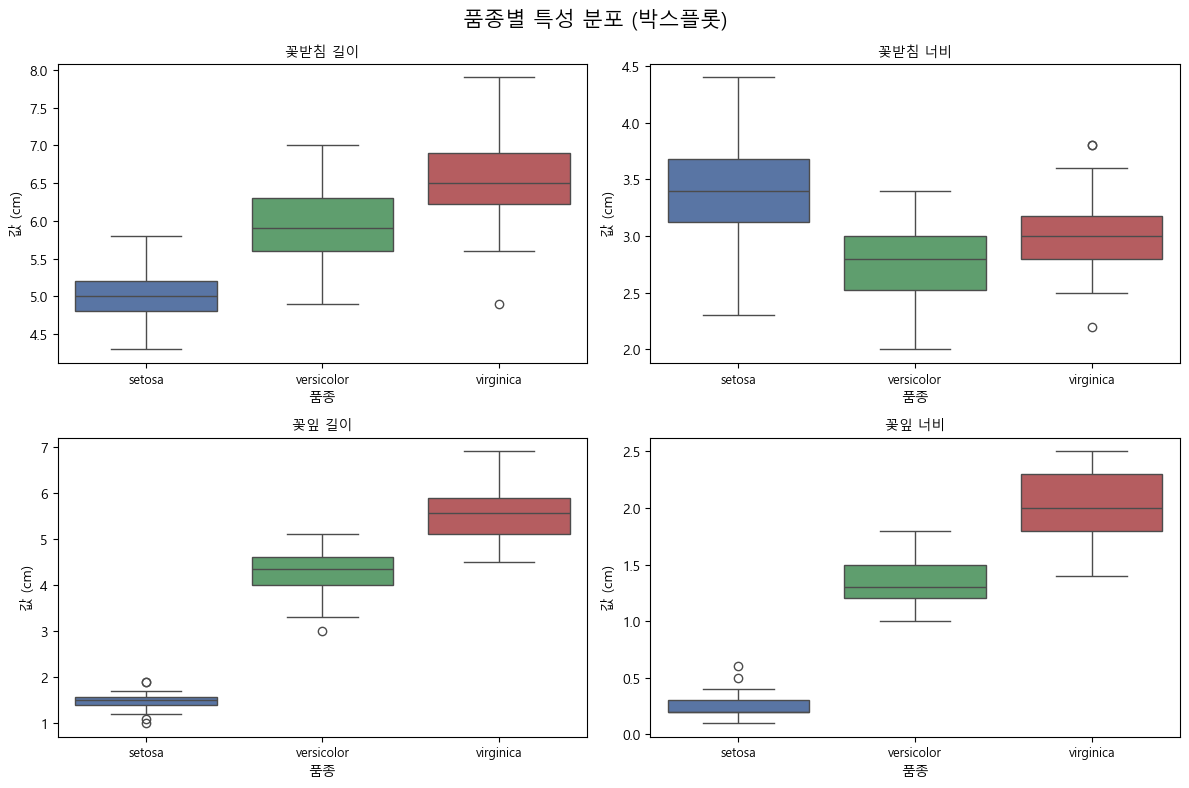

저장: 02_boxplot.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('품종별 특성 분포 (박스플롯)', fontsize=15, fontproperties=font_prop)

for ax, feat, label in zip(axes.flatten(), features, labels_ko):
    sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
    ax.set_title(label, fontproperties=font_prop)
    ax.set_xlabel('품종', fontproperties=font_prop)
    ax.set_ylabel('값 (cm)', fontproperties=font_prop)
    # x축 레이블 간소화
    ax.set_xticklabels(['setosa', 'versicolor', 'virginica'], fontsize=9)

plt.tight_layout()
plt.savefig('02_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 02_boxplot.png")

### 3. 산점도 행렬 (Pair Plot) - 특성 간 관계

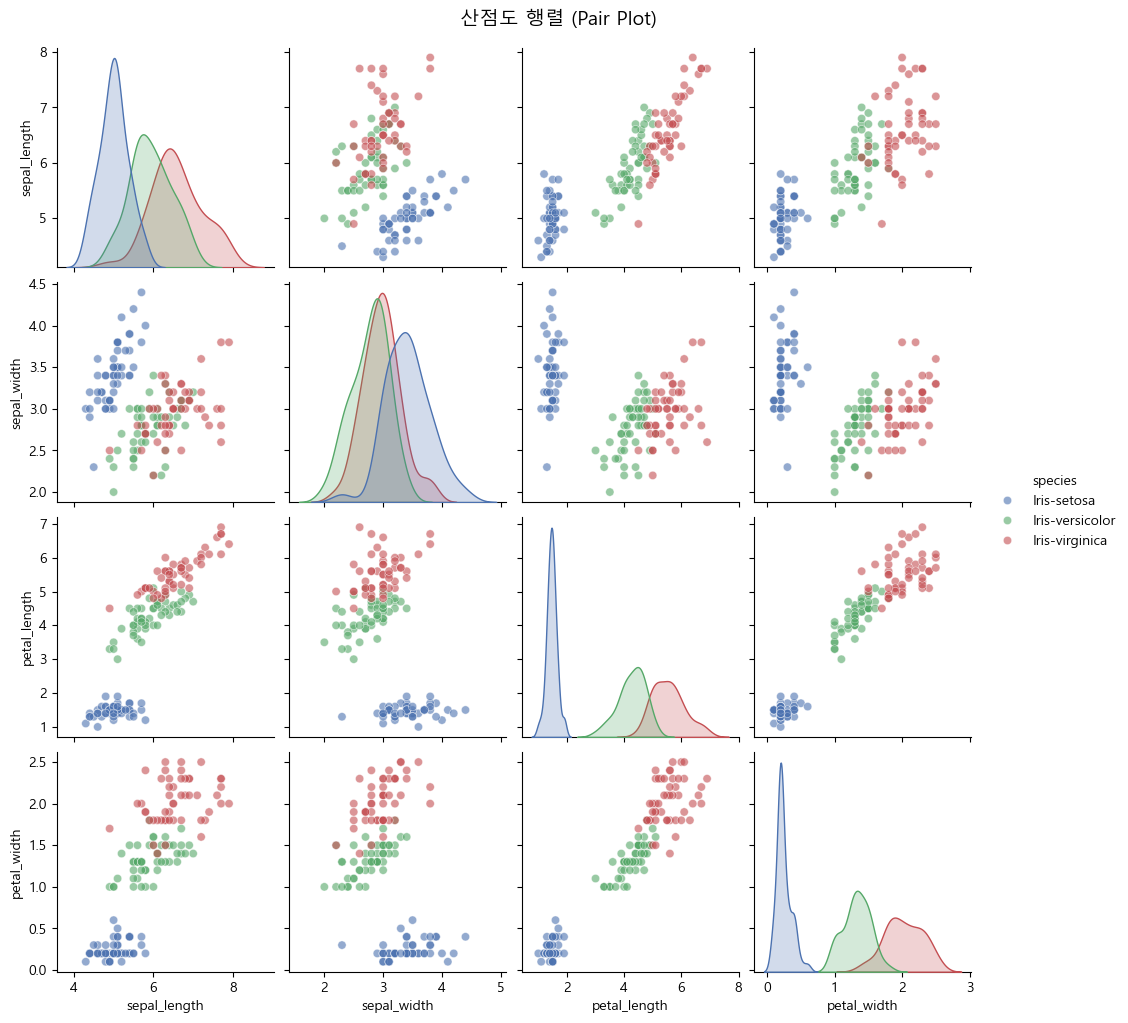

저장: 03_pairplot.png


In [16]:
# 품종별 색으로 구분된 산점도 행렬 — 클러스터 분리 가능성 확인
pair_grid = sns.pairplot(df, hue='species', palette=palette, diag_kind='kde', plot_kws={'alpha': 0.6})
pair_grid.fig.suptitle('산점도 행렬 (Pair Plot)', y=1.02, fontsize=14, fontproperties=font_prop)

plt.savefig('03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 03_pairplot.png")

### 4. 상관관계 히트맵

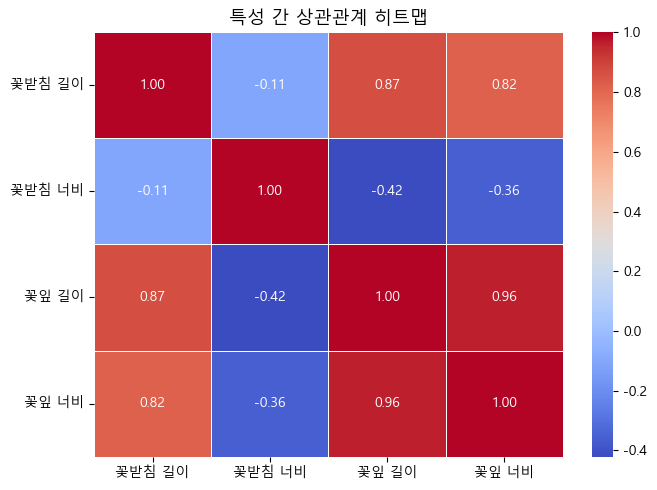

저장: 04_heatmap.png

=== 상관계수 테이블 ===


,꽃받침 길이,꽃받침 너비,꽃잎 길이,꽃잎 너비
꽃받침 길이,1.00,-0.11,0.87,0.82
꽃받침 너비,-0.11,1.00,-0.42,-0.36
꽃잎 길이,0.87,-0.42,1.00,0.96
꽃잎 너비,0.82,-0.36,0.96,1.00


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

# 수치형 컬럼만 상관계수 계산
corr = df[features].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=labels_ko, yticklabels=labels_ko,
            linewidths=0.5, ax=ax)

ax.set_title('특성 간 상관관계 히트맵', fontproperties=font_prop, fontsize=13)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('04_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 04_heatmap.png")

# 상관계수 수치 테이블 출력
print("\n=== 상관계수 테이블 ===")
corr_display = corr.copy()
corr_display.index = labels_ko
corr_display.columns = labels_ko
display(corr_display.round(2).style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}'))

In [ ]:
species_list = df['species'].unique()
species_labels = ['setosa', 'versicolor', 'virginica']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('품종별 상관관계 히트맵', fontsize=14, fontproperties=font_prop)

for ax, species, label in zip(axes, species_list, species_labels):
    # 해당 품종 데이터만 추출하여 상관계수 계산
    corr_s = df[df['species'] == species][features].corr()

    # 대각선 위 삼각형 마스킹 (중복 제거)
    mask = np.triu(np.ones_like(corr_s, dtype=bool), k=1)

    sns.heatmap(corr_s, annot=True, fmt='.2f', cmap='coolwarm',
                xticklabels=labels_ko, yticklabels=labels_ko,
                mask=mask, linewidths=0.5, vmin=-1, vmax=1, ax=ax)

    ax.set_title(label, fontsize=12)
    plt.setp(ax.get_xticklabels(), fontproperties=font_prop, fontsize=8)
    plt.setp(ax.get_yticklabels(), fontproperties=font_prop, fontsize=8, rotation=0)

plt.tight_layout()
plt.savefig('04b_species_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 04b_species_corr_heatmap.png")

### 4-2. 품종 포함 전체 상관관계 히트맵

In [ ]:
# species를 숫자로 인코딩 (setosa=0, versicolor=1, virginica=2)
df_encoded = df.copy()
df_encoded['species_code'] = LabelEncoder().fit_transform(df['species'])
df_encoded = df_encoded.drop(columns='species')

# 컬럼명 한글 변환
col_labels = labels_ko + ['품종(숫자)']
corr_full = df_encoded.corr()
corr_full.index = col_labels
corr_full.columns = col_labels

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11})

ax.set_title('전체 특성 + 품종 상관관계 히트맵', fontproperties=font_prop, fontsize=13)
plt.xticks(fontproperties=font_prop, rotation=30, ha='right')
plt.yticks(fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('04c_full_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 04c_full_corr_heatmap.png")

# 품종과의 상관계수만 따로 출력
print("\n=== 품종(species)과 각 특성의 상관계수 ===")
print(corr_full['품종(숫자)'].drop('품종(숫자)').sort_values(ascending=False).to_string())

### 5. 품종별 특성 평균 히트맵

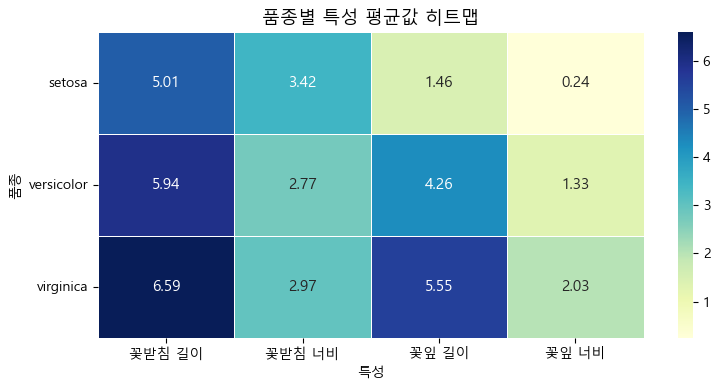

저장: 05_species_heatmap.png


,꽃받침 길이,꽃받침 너비,꽃잎 길이,꽃잎 너비
setosa,5.01,3.42,1.46,0.24
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [21]:
# 품종별 특성 평균값 피벗 테이블 생성
pivot = df.groupby('species')[features].mean()
pivot.index = ['setosa', 'versicolor', 'virginica']
pivot.columns = labels_ko

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, annot_kws={'size': 11})

ax.set_title('품종별 특성 평균값 히트맵', fontproperties=font_prop, fontsize=13)
ax.set_xlabel('특성', fontproperties=font_prop)
ax.set_ylabel('품종', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('05_species_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 05_species_heatmap.png")

# 수치 테이블도 함께 출력
display(pivot.style.background_gradient(cmap='YlGnBu').format('{:.2f}'))

~~~
=== 품종(species)과 각 특성의 상관계수 ===
꽃잎 너비     0.956464
꽃잎 길이     0.949043
꽃받침 길이    0.782561
꽃받침 너비   -0.419446

● 품종과 각 특성의 상관계수 해석    

  ┌─────────────┬──────────┬──────────────────────────────────────────────────────┐                                                                  │    특성      │ 상관계수  │                         해석                         │
  ├─────────────┼──────────┼──────────────────────────────────────────────────────┤                                            
  │ 꽃잎 너비    │ +0.96    │ 꽃잎이 넓을수록 virginica에 가까움. 품종 구분력 최강       │
  ├─────────────┼──────────┼──────────────────────────────────────────────────────┤
  │ 꽃잎 길이    │ +0.95    │ 꽃잎이 길수록 virginica에 가까움. 거의 동등한 구분력       │
  ├─────────────┼──────────┼──────────────────────────────────────────────────────┤
  │ 꽃받침 길이  │ +0.78    │ 어느 정도 유용하지만 위 두 특성보다 약함                   │
  ├─────────────┼──────────┼──────────────────────────────────────────────────────┤
  │ 꽃받침 너비  │ -0.42    │ 약한 음의 관계. setosa가 꽃받침 너비가 넓은 경향           │
  └─────────────┴──────────┴──────────────────────────────────────────────────────┘

  ▎ 품종은 setosa=0, versicolor=1, virginica=2로 인코딩되었으므로,
  ▎ 양수 = 숫자가 큰 품종(virginica)일수록 값이 크다는 의미

  ---
  ML에서의 활용

  1. Feature Selection (특성 선택)
  - 꽃잎 너비(0.96), 꽃잎 길이(0.95)는 타겟(품종)과 상관이 매우 높음 → 우선 학습에 포함
  - 꽃받침 너비(-0.42)는 상관이 약함 → 모델 성능에 기여가 적을 수 있음

  2. 중복 특성 제거
  - 꽃잎 너비 ↔ 꽃잎 길이 상관계수가 0.96으로 거의 같은 정보
  - 둘 중 하나만 써도 정보 손실이 거의 없음 → 차원 축소 가능

  3. 모델 선택 힌트
  - 상관이 선형적으로 매우 높으므로 로지스틱 회귀만으로도 높은 정확도 기대
  - 꽃받침 너비처럼 비선형 관계가 섞여 있으면 Random Forest / SVM 같은 비선형 모델이 유리

  4. 실전 요약
  꽃잎 길이, 꽃잎 너비  → 핵심 특성 (반드시 포함)
  꽃받침 길이           → 보조 특성 (포함하면 소폭 향상)
  꽃받침 너비           → 노이즈에 가까움 (제거해도 무방)

  즉, 이 분석만으로도 "꽃잎 2개 특성으로 IRIS 품종을 거의 완벽히 분류할 수 있다" 는 결론을 내릴 수 있습니다.
~~~

## 머신러닝 모델 성능 비교

### 1단계. 데이터 준비 (전처리 + Train/Test 분할)

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# 특성(X)과 타겟(y) 분리
X = df[features].values
y = LabelEncoder().fit_transform(df['species'])  # setosa=0, versicolor=1, virginica=2

# 80% 학습 / 20% 테스트 분할 (random_state 고정으로 재현 가능)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 스케일링 (평균=0, 표준편차=1) — SVM·KNN·로지스틱 회귀에 필수
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")
print(f"클래스 분포 (학습): {dict(zip(*np.unique(y_train, return_counts=True)))}")

### 2단계. 모델 학습 및 성능 비교 (5-Fold 교차검증)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 비교할 모델 정의 (스케일된 데이터 사용 모델은 _sc 표시)
models = {
    '로지스틱 회귀':     (LogisticRegression(max_iter=200, random_state=42), True),
    'KNN (k=5)':        (KNeighborsClassifier(n_neighbors=5), True),
    'SVM (RBF)':        (SVC(kernel='rbf', random_state=42), True),
    '결정 트리':         (DecisionTreeClassifier(random_state=42), False),
    '랜덤 포레스트':     (RandomForestClassifier(n_estimators=100, random_state=42), False),
    '그래디언트 부스팅': (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
}

results = []
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    Xall = np.vstack([Xtr, Xte])  # 교차검증용 전체 데이터

    # 5-Fold 교차검증 (학습 데이터 기준)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')

    # 테스트셋 정확도
    model.fit(Xtr, y_train)
    test_acc = accuracy_score(y_test, model.predict(Xte))

    results.append({
        '모델': name,
        'CV 평균 정확도': cv_scores.mean(),
        'CV 표준편차': cv_scores.std(),
        '테스트 정확도': test_acc,
    })

result_df = pd.DataFrame(results).sort_values('테스트 정확도', ascending=False).reset_index(drop=True)
display(result_df.style.format({'CV 평균 정확도': '{:.4f}', 'CV 표준편차': '{:.4f}', '테스트 정확도': '{:.4f}'})\
        .background_gradient(subset=['테스트 정확도'], cmap='Greens'))

,모델,CV 평균 정확도,CV 표준편차,테스트 정확도
0,그래디언트 부스팅,0.9667,0.0167,0.9667
1,SVM (RBF),0.9667,0.0312,0.9667
2,KNN (k=5),0.9667,0.0312,0.9333
3,로지스틱 회귀,0.9583,0.0264,0.9333
4,결정 트리,0.9417,0.0204,0.9333
5,랜덤 포레스트,0.9500,0.0167,0.9000


### 3단계. 모델 정확도 시각화

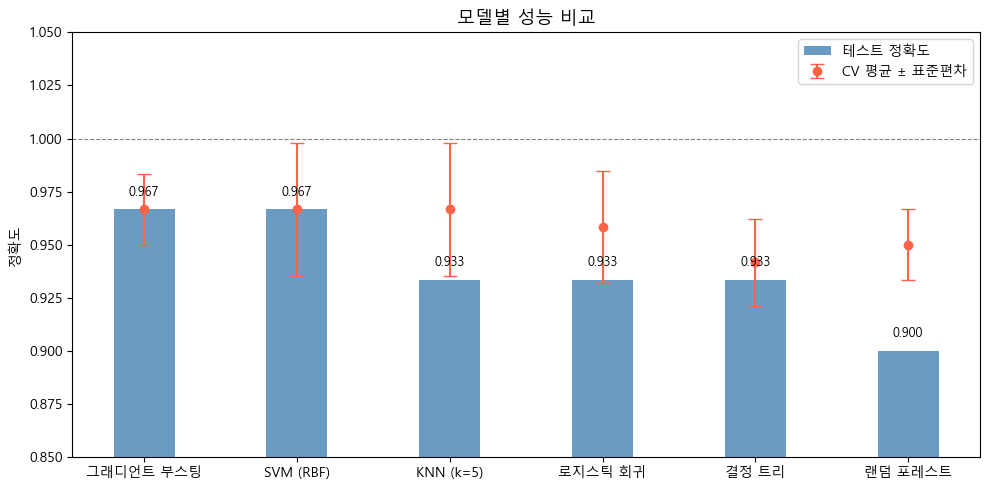

저장: 06_model_comparison.png


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(result_df))
bars = ax.bar(x, result_df['테스트 정확도'], width=0.4,
              color='steelblue', alpha=0.8, label='테스트 정확도')

# CV 평균 ± 표준편차 오차막대
ax.errorbar(x, result_df['CV 평균 정확도'], yerr=result_df['CV 표준편차'],
            fmt='o', color='tomato', capsize=5, label='CV 평균 ± 표준편차')

ax.set_xticks(x)
ax.set_xticklabels(result_df['모델'], fontproperties=font_prop, fontsize=10)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('정확도', fontproperties=font_prop)
ax.set_title('모델별 성능 비교', fontproperties=font_prop, fontsize=13)
ax.legend(prop=font_prop)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# 막대 위에 수치 표시
for bar, val in zip(bars, result_df['테스트 정확도']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 06_model_comparison.png")

### 4단계. 최적 모델 혼동 행렬 (Confusion Matrix)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 테스트 정확도 1위 모델 자동 선택
best_name = result_df.iloc[0]['모델']
best_model, best_scaled = models[best_name]
Xte_best = X_test_sc if best_scaled else X_test
y_pred = best_model.predict(Xte_best)

# species_labels = ['setosa', 'versicolor', 'virginica'] — eb131277 셀에서 정의됨
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_labels, yticklabels=species_labels,
            linewidths=0.5, ax=ax)
ax.set_title(f'혼동 행렬 — {best_name}', fontproperties=font_prop, fontsize=13)
ax.set_xlabel('예측 품종', fontproperties=font_prop)
ax.set_ylabel('실제 품종', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 07_confusion_matrix.png")

# 상세 분류 리포트
print(f"\n=== 분류 리포트 ({best_name}) ===")
print(classification_report(y_test, y_pred, target_names=species_labels))

### 5단계. 결정 경계 시각화 (Decision Boundary)

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

# PCA로 4차원 → 2차원 축소 (시각화 목적)
# 학습용 scaler와 별도로 사용해 기존 학습 스케일 파라미터를 덮어쓰지 않음
pca = PCA(n_components=2, random_state=42)
scaler_vis  = StandardScaler()
X_sc        = scaler_vis.fit_transform(X)
X_pca       = pca.fit_transform(X_sc)
X_train_pca = pca.transform(scaler_vis.transform(X_train))
X_test_pca  = pca.transform(scaler_vis.transform(X_test))

print(f"PCA 설명 분산 비율: {pca.explained_variance_ratio_}")
print(f"누적 설명력: {pca.explained_variance_ratio_.sum():.4f}")

# 결정 경계 색상
bg_colors = ['#AED6F1', '#A9DFBF', '#F1948A']   # 배경 (영역)
pt_colors = ['#1A5276', '#1E8449', '#922B21']    # 데이터 포인트
cmap_bg   = ListedColormap(bg_colors)

model_names = list(models.keys())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('모델별 결정 경계 (PCA 2D 투영)', fontsize=15, fontproperties=font_prop)

# 격자 범위 설정
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

for ax, name in zip(axes.flatten(), model_names):
    # PCA 공간에서 모델 재학습
    clf = models[name][0].__class__(**models[name][0].get_params())
    clf.fit(X_train_pca, y_train)

    # 격자 전체에 대해 예측 → 배경 색 채우기
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=0.5)

    # 학습/테스트 포인트 표시
    for cls, color in enumerate(pt_colors):
        ax.scatter(X_train_pca[y_train == cls, 0],
                   X_train_pca[y_train == cls, 1],
                   c=color, s=40, marker='o', edgecolors='k', linewidths=0.4)
        ax.scatter(X_test_pca[y_test == cls, 0],
                   X_test_pca[y_test == cls, 1],
                   c=color, s=80, marker='*', edgecolors='k', linewidths=0.4)

    acc = accuracy_score(y_test, clf.predict(X_test_pca))
    ax.set_title(f'{name}  (정확도: {acc:.3f})', fontproperties=font_prop, fontsize=10)
    ax.set_xlabel('PCA 1', fontsize=9)
    ax.set_ylabel('PCA 2', fontsize=9)

# 공통 범례 (● 학습  ★ 테스트)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=7, markeredgecolor='k', label='학습 데이터 (●)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
           markersize=10, markeredgecolor='k', label='테스트 데이터 (★)'),
]
fig.legend(handles=legend_elements, prop=font_prop,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('08_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: 08_decision_boundary.png")